# Process overview — SARIMAX workflow

This notebook runs an end-to-end SARIMAX modeling pipeline for CPI series. Below is a concise explanation of the full process so readers can quickly understand inputs, assumptions, and outputs.

1. Inputs and assumptions
- Input file: `inflationship_output/ports_with_cpi_full_totals.csv`.
- Time index: monthly `date` column (YYYY-MM or parseable monthly dates). The code coerces `date` to a DatetimeIndex and sorts data by time.
- Target variables: CPI series (e.g., `cpi_all`, `cpi_food`, `cpi_apparel`, `cpi_vehicles`, `cpi_pharma`, `cpi_household`). The code only models CPI columns present in the CSV.
- Exogenous regressors (optional): `total_teus` and `importprice` (if present) can be used as exogenous variables (exog) to condition CPI forecasts on port activity and import prices.

2. Modeling steps
- Data readiness: ensure monthly frequency, coerce numeric types, and drop short series (<~24 months) to avoid unstable seasonal fits.
- Order selection: attempt automatic order selection with `pmdarima.auto_arima` (supports exogenous regressors). If `pmdarima` is not available or fails, run a conservative manual grid search over small (p,q,P,Q) values and pick the model with the lowest AIC.
- Fitting: fit SARIMAX with the chosen (p,d,q) and seasonal (P,D,Q,s) orders. If exogenous regressors are used, align and clean them (ffill/bfill) before fitting.
- Forecasting: produce a 12-month forecast. If exogenous regressors are used, the notebook builds a future exog matrix via one of:
  - forecasting each exog with `auto_arima` (if available), or
  - a persistence baseline that repeats the last observed exog values for each future month.

3. Diagnostics and evaluation
- In-sample diagnostics: AIC, residual analysis (Ljung–Box tests, Durbin–Watson), and in-sample MAPE for recent observations.
- Out-of-sample evaluation: train/test split (last 12 months) with OOS MAPE computed using the chosen exog forecasting method.
- Visual checks: residual time-series plots and forecast vs observed plots (last 36 months + forecast horizon).

4. Outputs
- `results_summary` (in-memory): stores fitted model objects and metadata (orders, AIC).
- `metrics_df` / `sarimax_metrics_summary.csv`: summary table with AIC, in-sample and OOS MAPE, Durbin–Watson, Ljung–Box p-values, and sample size.

5. Practical tips
- For better exog forecasts, fit separate ARIMA/SARIMA models for `total_teus` and `importprice` rather than using persistence.
- Check multicollinearity (VIF) among exog variables before relying on coefficient estimates.
- Use rolling-origin cross-validation for robust forecast evaluation instead of a single train/test split.
- Save fitted model objects (pickle) if you want to reuse models for production forecasts.

Run order: execute the notebook top-to-bottom (imports & data load -> SARIMAX modeling cell -> diagnostics & metrics cells).

CPI columns to model: ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
auto_arima not usable — falling back to manual grid search. Error: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Grid-search SARIMA for cpi_all (small grid)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Grid selected order=(2, 1, 2), seasonal_order=(0, 1, 1, 12), AIC=213.45
Fitting final SARIMAX for cpi_all: order=(2, 1, 2) seasonal_order=(0, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                              cpi_all   No. Observations:                  128
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                 -99.725
Date:                              Thu, 23 Oct 2025   AIC                            213.449
Time:                                      00:14:51   BIC                            231.685
Sample:                                  01-01-2015   HQIC                           220.830
                                       - 08-01-2025                                         
Covariance Type:                                opg                                         


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


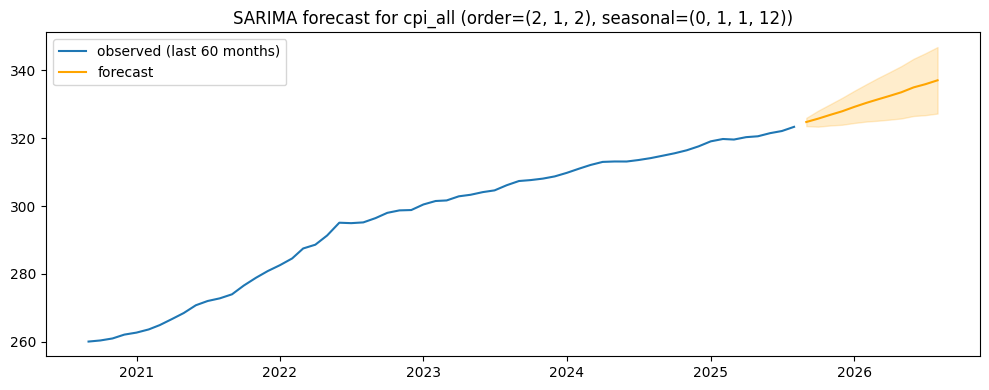

Grid-search SARIMA for cpi_food (small grid)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Grid selected order=(1, 1, 1), seasonal_order=(0, 1, 1, 12), AIC=200.92
Fitting final SARIMAX for cpi_food: order=(1, 1, 1) seasonal_order=(0, 1, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                           cpi_food   No. Observations:                  128
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -95.459
Date:                            Thu, 23 Oct 2025   AIC                            200.917
Time:                                    00:14:54   BIC                            213.993
Sample:                                01-01-2015   HQIC                           206.210
                                     - 08-01-2025                                         
Covariance Type:                              opg                                         


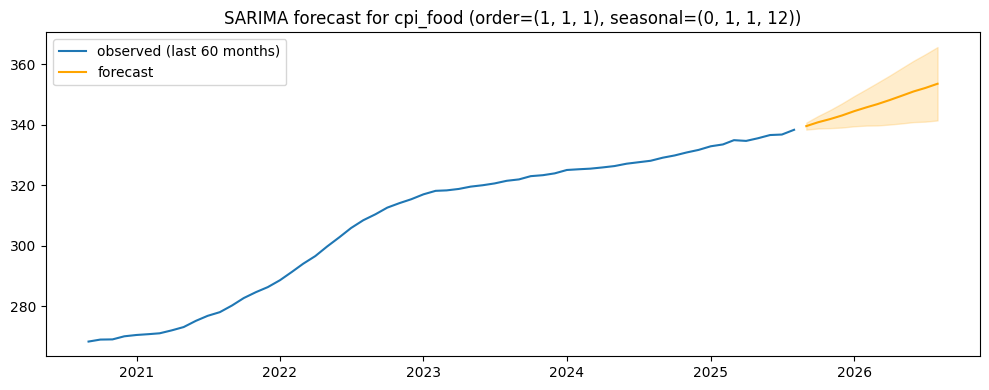

Grid-search SARIMA for cpi_apparel (small grid)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Grid selected order=(0, 1, 2), seasonal_order=(0, 1, 1, 12), AIC=281.84
Fitting final SARIMAX for cpi_apparel: order=(0, 1, 2) seasonal_order=(0, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                          cpi_apparel   No. Observations:                  128
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -135.920
Date:                              Thu, 23 Oct 2025   AIC                            281.841
Time:                                      00:14:57   BIC                            294.866
Sample:                                  01-01-2015   HQIC                           287.112
                                       - 08-01-2025                                         
Covariance Type:                                opg                                         


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


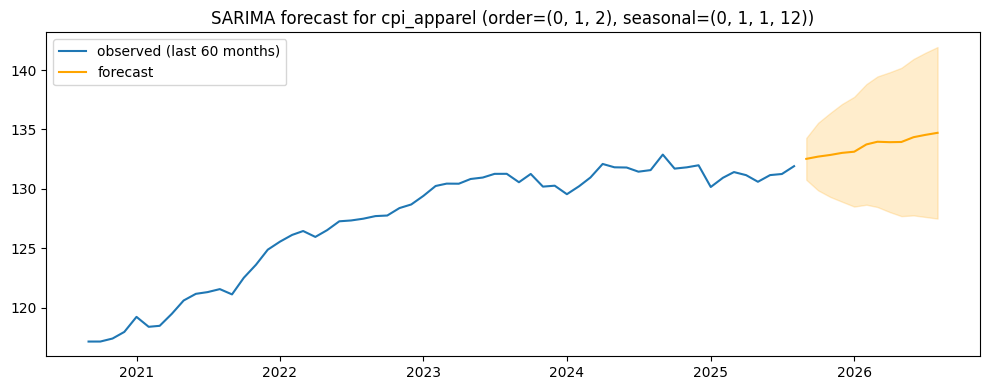

Grid-search SARIMA for cpi_vehicles (small grid)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Grid selected order=(1, 1, 2), seasonal_order=(0, 1, 1, 12), AIC=174.69
Fitting final SARIMAX for cpi_vehicles: order=(1, 1, 2) seasonal_order=(0, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                         cpi_vehicles   No. Observations:                  128
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood                 -81.345
Date:                              Thu, 23 Oct 2025   AIC                            174.691
Time:                                      00:15:02   BIC                            190.322
Sample:                                  01-01-2015   HQIC                           181.017
                                       - 08-01-2025                                         
Covariance Type:                                opg                                         


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


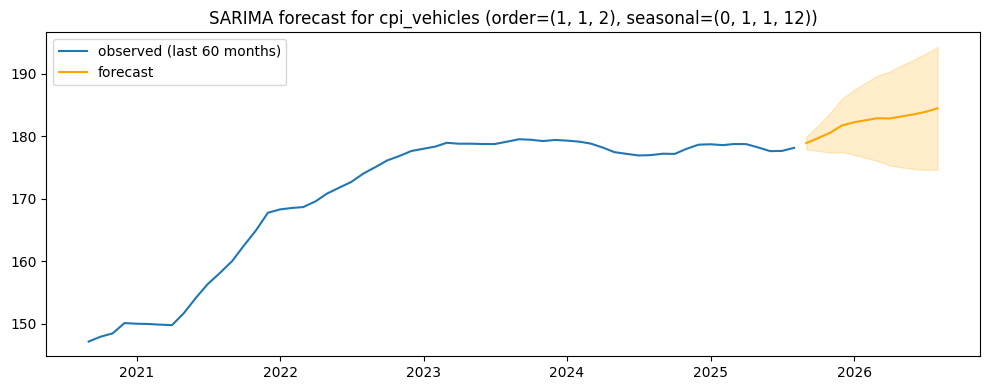

Grid-search SARIMA for cpi_pharma (small grid)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Grid selected order=(0, 1, 2), seasonal_order=(1, 1, 1, 12), AIC=354.37
Fitting final SARIMAX for cpi_pharma: order=(0, 1, 2) seasonal_order=(1, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                           cpi_pharma   No. Observations:                  128
Model:             SARIMAX(0, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -171.184
Date:                              Thu, 23 Oct 2025   AIC                            354.369
Time:                                      00:15:04   BIC                            370.000
Sample:                                  01-01-2015   HQIC                           360.695
                                       - 08-01-2025                                         
Covariance Type:                                opg                                         


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


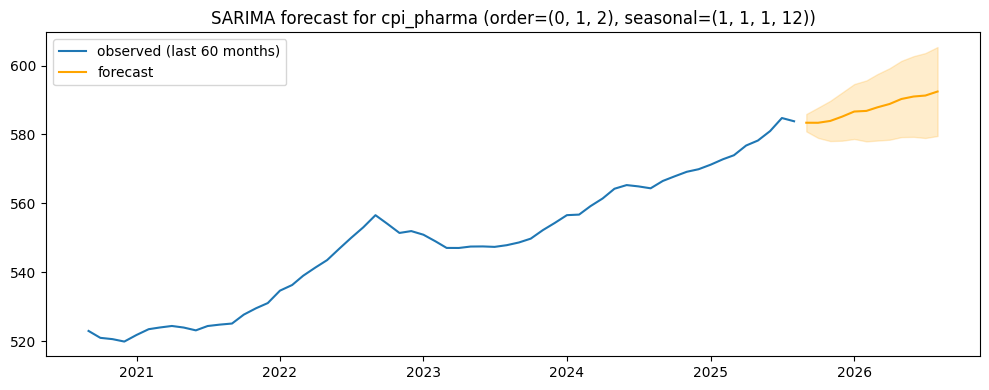

Grid-search SARIMA for cpi_household (small grid)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Grid selected order=(1, 1, 1), seasonal_order=(0, 1, 1, 12), AIC=93.19
Fitting final SARIMAX for cpi_household: order=(1, 1, 1) seasonal_order=(0, 1, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                      cpi_household   No. Observations:                  128
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -41.597
Date:                            Thu, 23 Oct 2025   AIC                             93.194
Time:                                    00:15:08   BIC                            106.270
Sample:                                01-01-2015   HQIC                            98.488
                                     - 08-01-2025                                         
Covariance Type:                              opg                                         


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


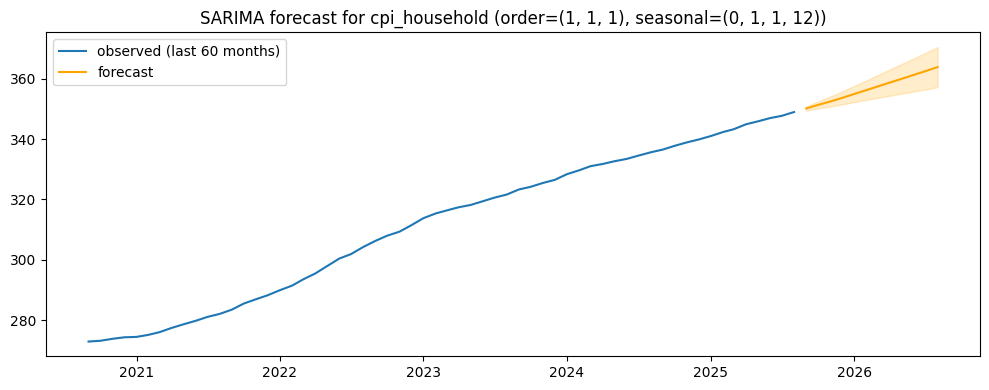


All done. Summary of fitted series:
cpi_all AIC: 213.45 order: (2, 1, 2) seasonal: (0, 1, 1, 12)
cpi_food AIC: 200.92 order: (1, 1, 1) seasonal: (0, 1, 1, 12)
cpi_apparel AIC: 281.84 order: (0, 1, 2) seasonal: (0, 1, 1, 12)
cpi_vehicles AIC: 174.69 order: (1, 1, 2) seasonal: (0, 1, 1, 12)
cpi_pharma AIC: 354.37 order: (0, 1, 2) seasonal: (1, 1, 1, 12)
cpi_household AIC: 93.19 order: (1, 1, 1) seasonal: (0, 1, 1, 12)


In [1]:
# SARIMA forecasting workflow with auto_arima fallback to manual grid (safe to run after restarting kernel)
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# load data
df = pd.read_csv("inflationship_output/ports_with_cpi_full_totals.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').set_index('date')

# CPI list (keep only present columns)
cpi_cols = ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
cpi_cols = [c for c in cpi_cols if c in df.columns]
print("CPI columns to model:", cpi_cols)

# ensure numeric
df[cpi_cols] = df[cpi_cols].apply(pd.to_numeric, errors='coerce')

# helper: ensure monthly frequency (if your series is monthly)
def ensure_monthly(series):
    # try infer freq; if missing set to MS based on index
    s = series.copy()
    if s.index.inferred_freq is None:
        # resample forward-fill to monthly start
        s = s.asfreq('MS')
    return s

# Try to import auto_arima (pmdarima); if not available we'll fall back
use_auto = True
try:
    from pmdarima import auto_arima
    print("auto_arima available — will attempt automatic order selection.")
except Exception as e:
    print("auto_arima not usable — falling back to manual grid search. Error:", e)
    use_auto = False

# model / forecast results container
results_summary = {}

for col in cpi_cols:
    series = df[col].dropna()
    if len(series) < 24:
        print(f"Skipping {col}: insufficient data (need ~24+ months). Has {len(series)} rows.")
        continue

    # ensure monthly frequency
    series = series.asfreq('MS') if series.index.inferred_freq is None else series

    if use_auto:
        try:
            print(f"\nRunning auto_arima for {col} ... (this can take a little while)")
            stepwise = auto_arima(
                series,
                start_p=0, start_q=0,
                max_p=3, max_q=3,
                start_P=0, start_Q=0,
                max_P=2, max_Q=2,
                seasonal=True, m=12,
                d=None, D=None,        # let auto_arima choose d/D
                trace=False,
                error_action="ignore",
                suppress_warnings=True,
                stepwise=True,
                n_jobs=1
            )
            order = stepwise.order
            seasonal_order = stepwise.seasonal_order
            print(f"auto_arima chosen order={order}, seasonal_order={seasonal_order}, AIC={stepwise.aic():.2f}")
        except Exception as e:
            print("auto_arima failed for", col, " — falling back to grid. Error:", e)
            use_local_grid = True
            order = None
            seasonal_order = None
    else:
        order = None
        seasonal_order = None

    # If auto_arima did not produce an order, run a small grid search
    if order is None:
        print(f"Grid-search SARIMA for {col} (small grid)...")
        import itertools
        best_aic = np.inf
        best_order = None
        best_seasonal = None
        p_vals = [0,1,2]
        q_vals = [0,1,2]
        P_vals = [0,1]
        Q_vals = [0,1]
        d = 1
        D = 1
        s = 12
        for p,q in itertools.product(p_vals, q_vals):
            for P,Q in itertools.product(P_vals, Q_vals):
                try:
                    mod = SARIMAX(series, order=(p,d,q), seasonal_order=(P,D,Q,s),
                                  enforce_stationarity=False, enforce_invertibility=False, trend='c')
                    res = mod.fit(disp=False, maxiter=200)
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = (p,d,q)
                        best_seasonal = (P,D,Q,s)
                    # print progress minimally
                except Exception:
                    continue
        if best_order is None:
            print("Grid search failed to find a stable model for", col)
            continue
        order = best_order
        seasonal_order = best_seasonal
        print(f"Grid selected order={order}, seasonal_order={seasonal_order}, AIC={best_aic:.2f}")

    # Fit final SARIMAX with selected orders
    try:
        print(f"Fitting final SARIMAX for {col}: order={order} seasonal_order={seasonal_order}")
        model = SARIMAX(series, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False, trend='c')
        res = model.fit(disp=False, maxiter=200)
        print(res.summary().tables[0])
        results_summary[col] = {"model": res, "order": order, "seasonal_order": seasonal_order, "aic": res.aic}
    except Exception as e:
        print("Final fit failed for", col, " — error:", e)
        continue

    # Forecast 12 months
    steps = 12
    try:
        fc = res.get_forecast(steps=steps)
        mean = fc.predicted_mean
        ci = fc.conf_int()
        plt.figure(figsize=(10,4))
        plt.plot(series[-60:], label='observed (last 60 months)')
        plt.plot(mean, label='forecast', color='orange')
        plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color='orange', alpha=0.2)
        plt.title(f"SARIMA forecast for {col} (order={order}, seasonal={seasonal_order})")
        plt.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Forecast failed for", col, " — error:", e)

print("\nAll done. Summary of fitted series:")
for k,v in results_summary.items():
    print(k, "AIC:", round(v['aic'],2), "order:", v['order'], "seasonal:", v['seasonal_order'])

In [2]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(series[-12:], res.fittedvalues[-12:])
print("MAPE:", mape)


MAPE: 0.0006695264513752194


In [3]:
train = series.iloc[:-12]   # all but last 12 months
test  = series.iloc[-12:]   # last 12 months

model = SARIMAX(train, order=(2,1,2), seasonal_order=(0,1,1,12))
res = model.fit(disp=False)

forecast = res.get_forecast(steps=12)
pred = forecast.predicted_mean

# Compute MAPE on unseen data
from sklearn.metrics import mean_absolute_percentage_error
mape_out = mean_absolute_percentage_error(test, pred)
print(f"Out-of-sample MAPE: {mape_out:.4f}")



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Out-of-sample MAPE: 0.0021
